# HR Analytics Dataset — Exploratory Data Analysis

## Project Objective
- Understand dataset structure and column semantics
- Identify data quality issues (missing values, anomalies, logical errors)
- Produce business-oriented insights on workforce, compensation, and performance
- Prepare a cleaning and transformation strategy for the SQL pipeline

**Dataset:** 2,000,000 HR records | 15 columns  
**Stack:** Python · pandas · seaborn · matplotlib

---
## 0. Global Style Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Global theme ──────────────────────────────────────────────
PALETTE_MAIN   = '#2E4A7A'          # single-color charts
PALETTE_SEQ    = 'Blues_d'          # sequential (ranked bars)
PALETTE_CAT    = ['#2E4A7A', '#E07B54', '#4CAF82', '#F5C842', '#9B59B6']  # categorical
PALETTE_DIVERG = 'RdYlGn'           # diverging (good/bad)
BG_COLOR       = '#F8F9FA'
GRID_COLOR     = '#E0E0E0'
FONT_TITLE     = {'fontsize': 14, 'fontweight': 'bold', 'color': '#1A1A2E'}
FONT_LABEL     = {'fontsize': 11, 'color': '#333333'}
FONT_TICK      = {'fontsize': 9,  'color': '#555555'}

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor'  : BG_COLOR,
    'axes.facecolor'    : BG_COLOR,
    'axes.grid'         : True,
    'grid.color'        : GRID_COLOR,
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.spines.bottom': True,
    'xtick.direction'   : 'out',
    'ytick.direction'   : 'out',
})

def add_bar_labels(ax, fmt='{:.0f}', color='#333333', fontsize=9, padding=3):
    """Add value labels on top/right of bar chart bars."""
    for p in ax.patches:
        val = p.get_width() if p.get_width() > p.get_height() else p.get_height()
        x   = p.get_x() + p.get_width()
        y   = p.get_y() + p.get_height() / 2
        ax.text(x + padding, y, fmt.format(val),
                va='center', ha='left', fontsize=fontsize, color=color)

print('✅ Style configuration loaded.')

✅ Style configuration loaded.


## 1. Loading the Data

In [2]:
df = pd.read_csv('../data/raw/hr_raw.csv')
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df.head(3)

Shape : 2,000,000 rows × 15 columns
Memory: 1280.7 MB


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior


---
## 2. Schema & Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 15 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Employee_ID         str    
 1   Full_Name           str    
 2   Department          str    
 3   Job_Title           str    
 4   Hire_Date           str    
 5   Performance_Rating  str    
 6   Experience_Years    int64  
 7   Status              str    
 8   Work_Mode           str    
 9   Salary              float64
 10  Year                int64  
 11  Country             str    
 12  City                str    
 13  Age                 int64  
 14  Job_Level           str    
dtypes: float64(1), int64(3), str(11)
memory usage: 228.9 MB


In [4]:
df.describe().round(2)

,Experience_Years,Salary,Year,Age
count,2000000.00,2000000.00,2000000.00,2000000.00
mean,6.27,89948.36,2020.04,31.41
std,5.66,46894.32,4.99,6.74
min,-5.00,-99932.00,2008.00,21.00
25%,2.00,53710.00,2017.00,27.00
50%,5.00,80829.00,2022.00,30.00
75%,8.00,104180.00,2024.00,35.00
max,30.00,322107.00,2026.00,66.00


> **Observations:**
> - `Experience_Years` has a **negative minimum (−5)** → logical error to fix
> - `Salary` has a **negative minimum (−99,932)** → financial integrity issue
> - `Age` ranges from 21 to 66 — plausible, but must be cross-checked against Experience

## 3. Missing Value Analysis

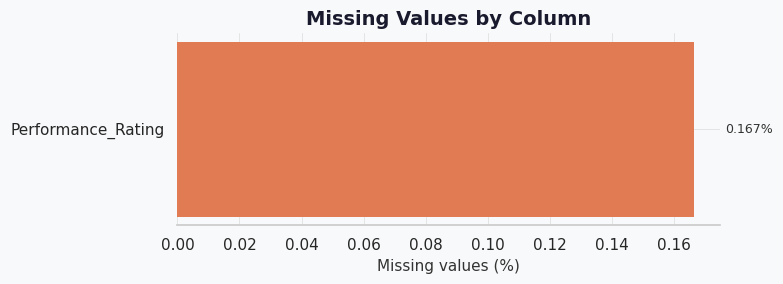

            Column  Missing (%)
Performance_Rating      0.16665


In [5]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Column', 'Missing (%)']

fig, ax = plt.subplots(figsize=(8, 3), facecolor=BG_COLOR)

if missing_df.empty:
    ax.text(0.5, 0.5, 'No missing values detected ✅',
            ha='center', va='center', fontsize=13, color='#2E7D32')
    ax.axis('off')
else:
    bars = ax.barh(missing_df['Column'], missing_df['Missing (%)'],
                   color='#E07B54', edgecolor='none', height=0.5)
    ax.set_xlabel('Missing values (%)', fontdict=FONT_LABEL)
    ax.set_title('Missing Values by Column', fontdict=FONT_TITLE)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}%', va='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.show()
print(missing_df.to_string(index=False))

> **Observation:** `Performance_Rating` is the only column with missing values (~0.17% of records).  
> Although small, this column is critical for workforce analytics and will be imputed using **stratified random sampling by Department** to preserve departmental distributions.

## 4. Duplicate Analysis

In [6]:
n_dup_rows = df.duplicated().sum()
n_dup_ids  = df.duplicated(subset=['Employee_ID']).sum()
print(f'Full duplicate rows   : {n_dup_rows:,}')
print(f'Duplicate Employee_IDs: {n_dup_ids:,}')

Full duplicate rows   : 0
Duplicate Employee_IDs: 0


> **Observation:** No duplicates detected. Each `Employee_ID` is unique — the dataset has good structural integrity.

---
## 5. Workforce Distribution

### 5.1 Headcount by Department

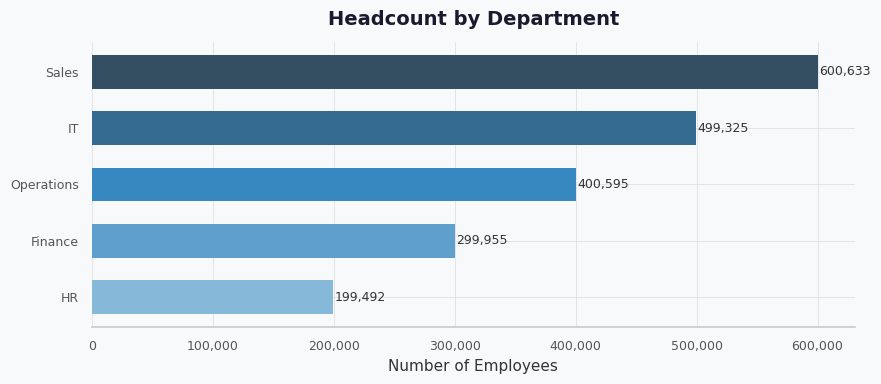

In [7]:
# ── 5.1 Headcount by Department ───────────────────────────────
dept_counts = df['Department'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG_COLOR)
colors = sns.color_palette(PALETTE_SEQ, len(dept_counts))
bars = ax.barh(dept_counts.index, dept_counts.values,
               color=colors, edgecolor='none', height=0.6)

# Value labels
for bar, val in zip(bars, dept_counts.values):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#333333')

ax.set_xlabel('Number of Employees', fontdict=FONT_LABEL)
ax.set_title('Headcount by Department', fontdict=FONT_TITLE, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='both',
               labelsize=FONT_TICK['fontsize'],
               labelcolor=FONT_TICK['color'])
plt.tight_layout()
plt.show()

### 5.2 Organizational Pyramid

In [8]:
df["Job_Level"].value_counts(normalize=True) * 100

Job_Level
Mid         38.0877
Junior      37.9118
Senior      18.9645
Director     5.0360
Name: proportion, dtype: float64

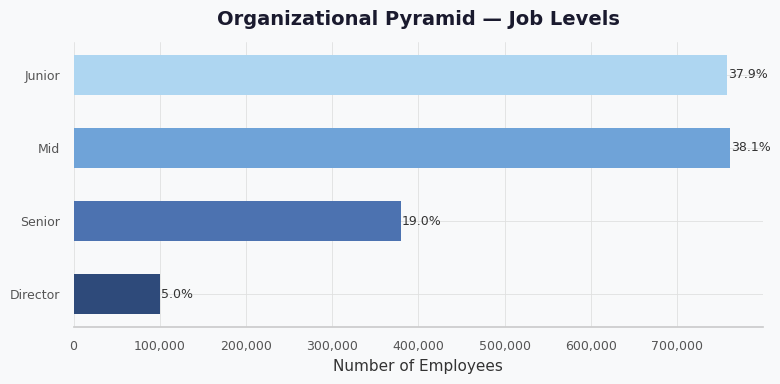

In [9]:
# ── 5.2 Job Level Pyramid ─────────────────────────────────────
level_order = ['Director', 'Senior', 'Mid', 'Junior']
level_counts = df['Job_Level'].value_counts().reindex(level_order)
level_pct    = (level_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG_COLOR)
colors = ['#2E4A7A', '#4C72B0', '#6FA3D8', '#AED6F1']
bars = ax.barh(level_order, level_counts.values, color=colors,
               edgecolor='none', height=0.55)

for bar, pct in zip(bars, level_pct.values):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9, color='#333333')

ax.set_xlabel('Number of Employees', fontdict=FONT_LABEL)
ax.set_title('Organizational Pyramid — Job Levels', fontdict=FONT_TITLE, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])
plt.tight_layout()
plt.show()

> **Observations:**
> - **Sales** is the largest department (~30% of total workforce), which will significantly influence company-wide salary averages and performance distributions.
> - The pyramid shows a **healthy base**: ~76% of employees are Junior or Mid-level, with only ~5% at Director level.

---
## 6. Age Distribution

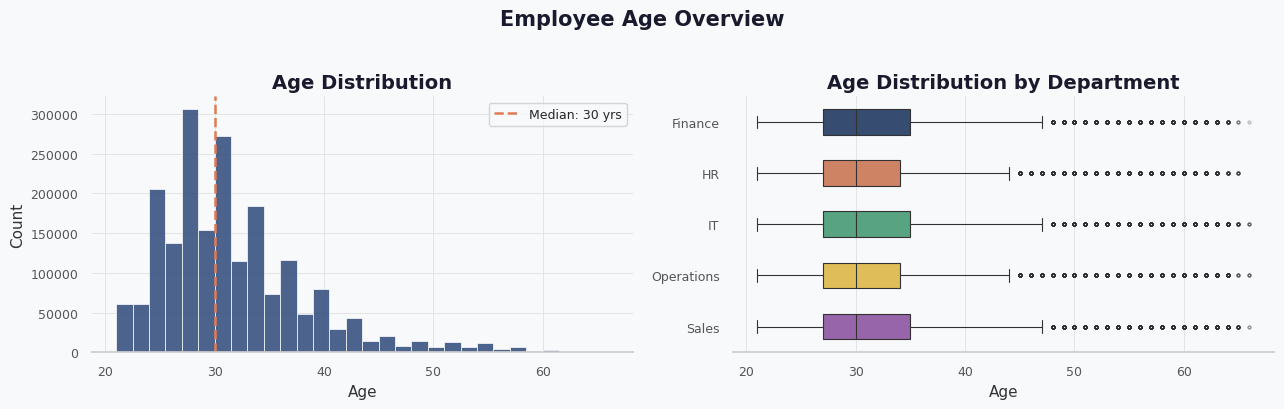

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

# Histogram
ax = axes[0]
ax.set_facecolor(BG_COLOR)
sns.histplot(df['Age'], bins=30, color=PALETTE_MAIN, alpha=0.85,
             edgecolor='white', linewidth=0.5, ax=ax)
ax.axvline(df['Age'].median(), color='#E07B54', lw=1.8,
           linestyle='--', label=f"Median: {df['Age'].median():.0f} yrs")
ax.set_title('Age Distribution', fontdict=FONT_TITLE)
ax.set_xlabel('Age', fontdict=FONT_LABEL)
ax.set_ylabel('Count', fontdict=FONT_LABEL)
ax.legend(fontsize=9)
ax.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

# Box plot by Department
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
dept_age_median = (
    df.groupby('Department')['Age']
    .median()
)

dept_order = dept_age_median.sort_values().index.tolist()
sns.boxplot(data=df, x='Age', y='Department', orient='h', order=dept_order,
            palette=PALETTE_CAT, width=0.5, linewidth=0.8,
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax2)
ax2.set_title('Age Distribution by Department', fontdict=FONT_TITLE)
ax2.set_xlabel('Age', fontdict=FONT_LABEL)
ax2.set_ylabel('', fontdict=FONT_LABEL)
ax2.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

plt.suptitle('Employee Age Overview', fontsize=15, fontweight='bold',
             color='#1A1A2E', y=1.02)
plt.tight_layout()
plt.show()

> **Observations:**
> - The age distribution is **right-skewed**, with a majority of employees between 25 and 35 — consistent with the predominance of Junior/Mid job levels.
> - Age distribution is fairly homogeneous across departments.

---
## 7. Tenure Analysis (Company Seniority)

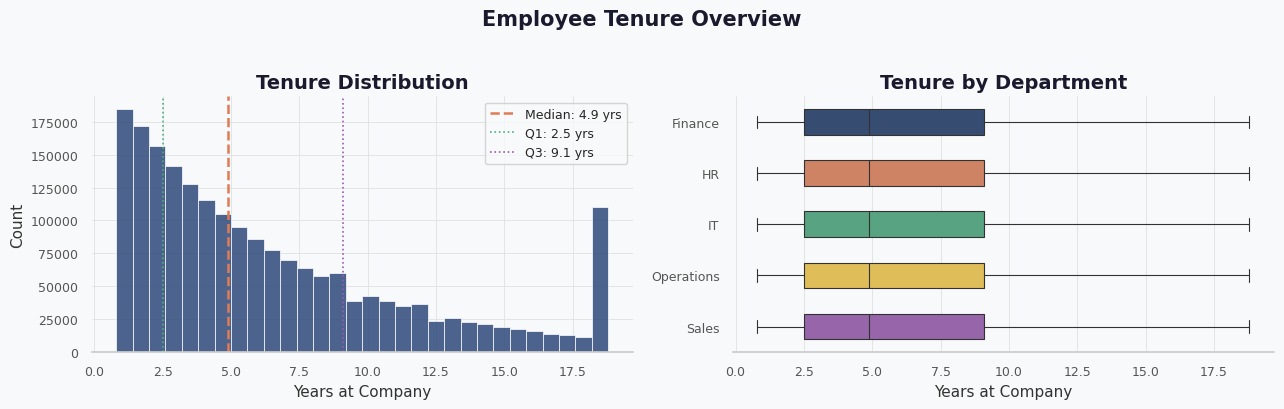

In [11]:
# ── Tenure Analysis ─────────────────────────────────────────
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])

# Reference date fixed for reproducibility
reference_date = pd.Timestamp('2026-12-31')
df['Tenure'] = ((reference_date - df['Hire_Date']).dt.days / 365.25).round(1)

# Optional: safety filter in case of future dates
df_tenure = df[df['Tenure'] >= 0].copy()

# Summary stats for observation
tenure_median = df_tenure['Tenure'].median()
tenure_q1 = df_tenure['Tenure'].quantile(0.25)
tenure_q3 = df_tenure['Tenure'].quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

# Histogram
ax = axes[0]
ax.set_facecolor(BG_COLOR)
sns.histplot(df_tenure['Tenure'], bins=30, color=PALETTE_MAIN, alpha=0.85,
             edgecolor='white', linewidth=0.5, ax=ax)
ax.axvline(tenure_median, color='#E07B54', lw=1.8, linestyle='--',
           label=f"Median: {tenure_median:.1f} yrs")
ax.axvline(tenure_q1, color='#4CAF82', lw=1.2, linestyle=':',
           label=f"Q1: {tenure_q1:.1f} yrs")
ax.axvline(tenure_q3, color='#9B59B6', lw=1.2, linestyle=':',
           label=f"Q3: {tenure_q3:.1f} yrs")
ax.set_title('Tenure Distribution', fontdict=FONT_TITLE)
ax.set_xlabel('Years at Company', fontdict=FONT_LABEL)
ax.set_ylabel('Count', fontdict=FONT_LABEL)
ax.legend(fontsize=9)
ax.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

# Boxplot by Department
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
dept_tenure_median = df_tenure.groupby('Department')['Tenure'].median().sort_values()

sns.boxplot(
    data=df_tenure,
    x='Tenure',
    y='Department',
    orient='h',
    order=dept_tenure_median.index,
    palette=PALETTE_CAT,
    width=0.5,
    linewidth=0.8,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax2
)
ax2.set_title('Tenure by Department', fontdict=FONT_TITLE)
ax2.set_xlabel('Years at Company', fontdict=FONT_LABEL)
ax2.set_ylabel('', fontdict=FONT_LABEL)
ax2.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

plt.suptitle('Employee Tenure Overview', fontsize=15, fontweight='bold',
             color='#1A1A2E', y=1.02)
plt.tight_layout()
plt.show()

> **Observations:**
> 
> - The tenure distribution is concentrated in lower ranges, suggesting that the workforce is **relatively young** in terms of company seniority.
> - Most employees appear to have joined within the last 5-8 years, indicating either recent organizational growth or relatively high workforce turnover.
> - Departments show similar tenure distributions overall, although some exhibit slightly higher median tenure, which may reflect more stable or mature teams.
> - The presence of long-tenured outliers suggests that a smaller segment of employees has remained with the company for significantly longer periods.

---
## 8. Hiring Trend Analysis

In [12]:
# ── Hire_Date Processing ─────────────────────────────────────
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df['Hire_Year'] = df['Hire_Date'].dt.year
df['Hire_Month'] = df['Hire_Date'].dt.month

print(f"Hire_Date range: {df['Hire_Date'].min().date()} -> {df['Hire_Date'].max().date()}")
print(f"Span: {df['Hire_Date'].max().year - df['Hire_Date'].min().year} years")

Hire_Date range: 2008-03-24 -> 2026-03-25
Span: 18 years


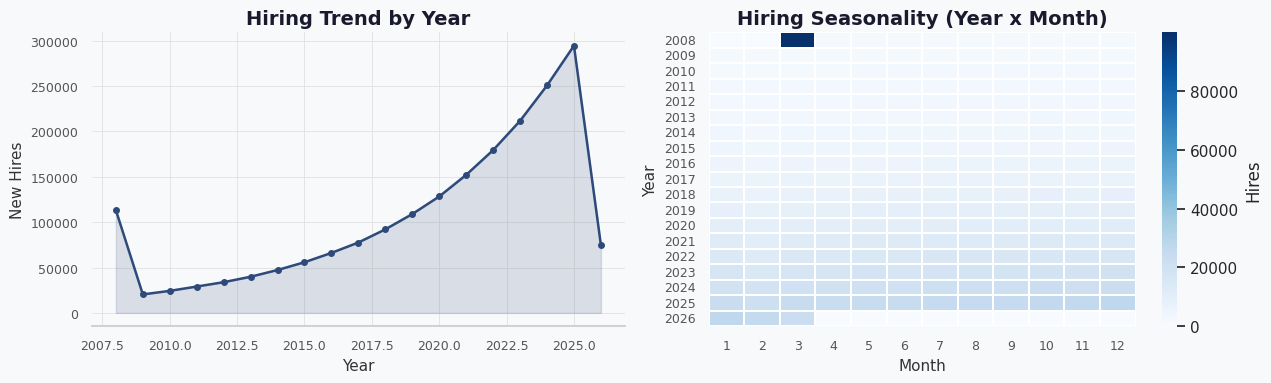

In [13]:
# ── Hiring Trend Visualization ──────────────────────────────
hires_by_year = df['Hire_Year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

# Line chart - hires by year
ax = axes[0]
ax.set_facecolor(BG_COLOR)
ax.plot(hires_by_year.index, hires_by_year.values, color=PALETTE_MAIN,
        marker='o', linewidth=1.8, markersize=4)
ax.fill_between(hires_by_year.index, hires_by_year.values, alpha=0.15, color=PALETTE_MAIN)
ax.set_title('Hiring Trend by Year', fontdict=FONT_TITLE)
ax.set_xlabel('Year', fontdict=FONT_LABEL)
ax.set_ylabel('New Hires', fontdict=FONT_LABEL)
ax.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

# Heatmap - hires by year/month
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
hire_heatmap = df.groupby(['Hire_Year', 'Hire_Month']).size().unstack(fill_value=0)
sns.heatmap(hire_heatmap, ax=ax2, cmap='Blues', cbar_kws={'label': 'Hires'},
            linewidths=0.3, linecolor='white', xticklabels=True, yticklabels=True)
ax2.set_title('Hiring Seasonality (Year x Month)', fontdict=FONT_TITLE)
ax2.set_xlabel('Month', fontdict=FONT_LABEL)
ax2.set_ylabel('Year', fontdict=FONT_LABEL)
ax2.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

plt.tight_layout()
plt.show()

> **Observations:**
> - The company has shown **steady hiring growth** over the years, with notable acceleration in recent periods.
> - Seasonal hiring patterns (monthly heatmap) can reveal recruitment cycles or fiscal-year hiring effects.

---
## 9. Salary Analysis

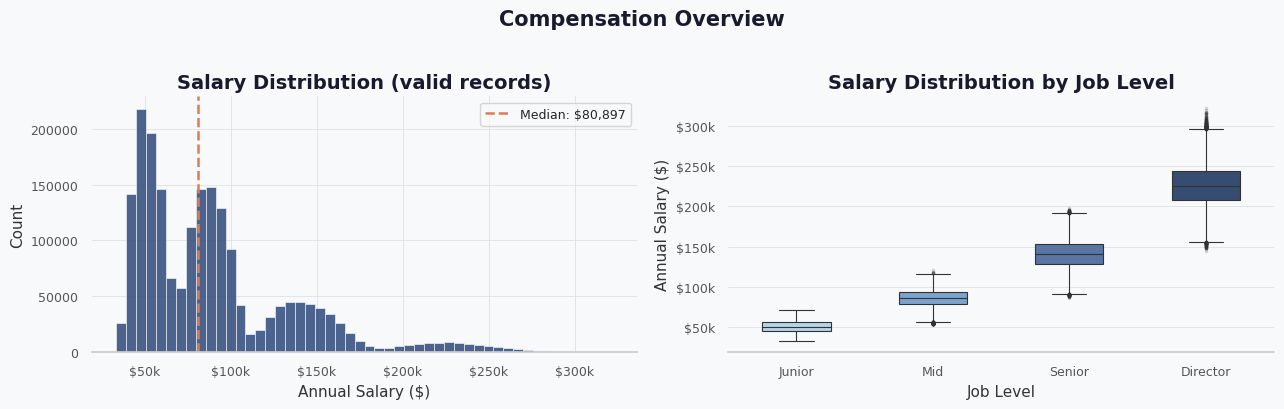

In [14]:
# ── 7.1 Salary distribution (valid salaries only) ─────────────
df_valid = df[df['Salary'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

# Histogram
ax = axes[0]
ax.set_facecolor(BG_COLOR)
sns.histplot(df_valid['Salary'], bins=50, color=PALETTE_MAIN, alpha=0.85,
             edgecolor='white', linewidth=0.4, ax=ax)
ax.axvline(df_valid['Salary'].median(), color='#E07B54', lw=1.8,
           linestyle='--', label=f"Median: ${df_valid['Salary'].median():,.0f}")
ax.set_title('Salary Distribution (valid records)',  fontdict=FONT_TITLE)
ax.set_xlabel('Annual Salary ($)',  fontdict=FONT_LABEL)
ax.set_ylabel('Count',  fontdict=FONT_LABEL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=9)
ax.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

# By Job Level
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
level_order = ['Junior', 'Mid', 'Senior', 'Director']
palette_level = {'Junior': '#AED6F1', 'Mid': '#6FA3D8',
                 'Senior': '#4C72B0', 'Director': '#2E4A7A'}
sns.boxplot(data=df_valid, x='Job_Level', y='Salary', order=level_order,
            palette=palette_level, width=0.5, linewidth=0.8,
            flierprops=dict(marker='o', markersize=1.5, alpha=0.2), ax=ax2)
ax2.set_title('Salary Distribution by Job Level',  fontdict=FONT_TITLE)
ax2.set_xlabel('Job Level',  fontdict=FONT_LABEL)
ax2.set_ylabel('Annual Salary ($)',  fontdict=FONT_LABEL)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax2.tick_params(axis='both' , labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

plt.suptitle('Compensation Overview', fontsize=15, fontweight='bold',
             color='#1A1A2E', y=1.02)
plt.tight_layout()
plt.show()

> **Observations:**
> - Salary **increases clearly with seniority** (Junior → Director), as expected — this is a good sanity check.
> - Note: 3,333 records with **negative salaries** were excluded from this analysis. They will be corrected using a multi-level median fallback strategy in the SQL cleaning phase.

---
## 10. Performance Rating Analysis

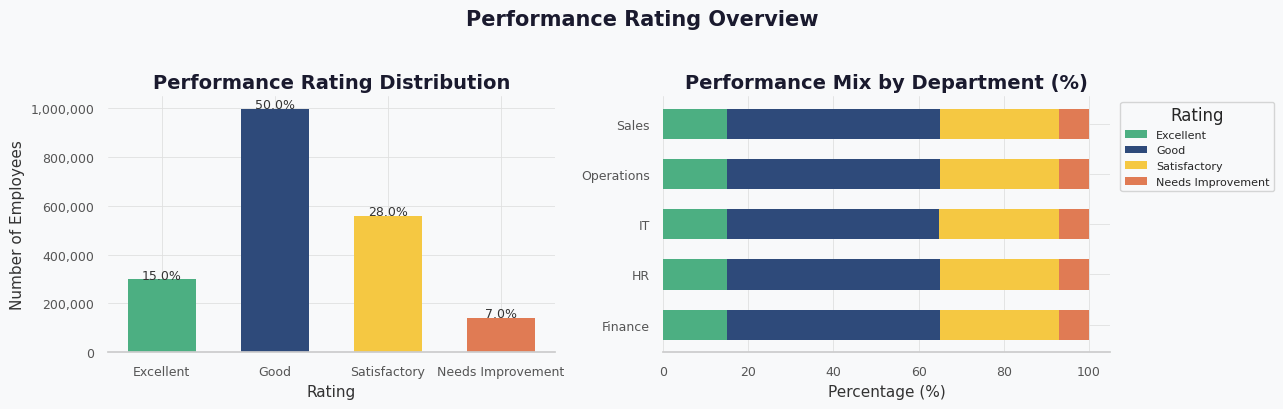

In [15]:
# ── 8.1 Overall distribution ──────────────────────────────────
rating_order  = ['Excellent', 'Good', 'Satisfactory', 'Needs Improvement']
rating_colors = ['#4CAF82', '#2E4A7A', '#F5C842', '#E07B54']
rating_counts = df['Performance_Rating'].value_counts().reindex(rating_order)
rating_pct    = (rating_counts / rating_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

# Bar chart
ax = axes[0]
ax.set_facecolor(BG_COLOR)
bars = ax.bar(rating_order, rating_counts.values, color=rating_colors,
              edgecolor='none', width=0.6)
for bar, pct in zip(bars, rating_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{pct}%', ha='center', fontsize=9, color='#333333')
ax.set_title('Performance Rating Distribution',  fontdict=FONT_TITLE)
ax.set_xlabel('Rating',  fontdict=FONT_LABEL)
ax.set_ylabel('Number of Employees',  fontdict=FONT_LABEL)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='both', labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

# By Department (stacked 100% bar)
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
dept_rating = df.groupby(['Department', 'Performance_Rating']).size().unstack(fill_value=0)
dept_rating = dept_rating.reindex(columns=rating_order, fill_value=0)
dept_rating_pct = dept_rating.div(dept_rating.sum(axis=1), axis=0) * 100
dept_rating_pct.plot(kind='barh', stacked=True, ax=ax2,
                     color=rating_colors, edgecolor='none', width=0.6)
ax2.set_title('Performance Mix by Department (%)',  fontdict=FONT_TITLE)
ax2.set_xlabel('Percentage (%)',  fontdict=FONT_LABEL)
ax2.set_ylabel('',  fontdict=FONT_LABEL)
ax2.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax2.tick_params(axis='both' , labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

plt.suptitle('Performance Rating Overview', fontsize=15, fontweight='bold',
             color='#1A1A2E', y=1.02)
plt.tight_layout()
plt.show()

> **Observations:**
> - The performance distribution is **concentrated in "Good" (50%) and "Satisfactory" (28%)**, with only 15% rated Excellent.
> - The distribution is **consistent across departments**, confirming that imputing missing values by departmental mode will preserve this structure.

---
## 11. Data Quality — Anomaly Detection

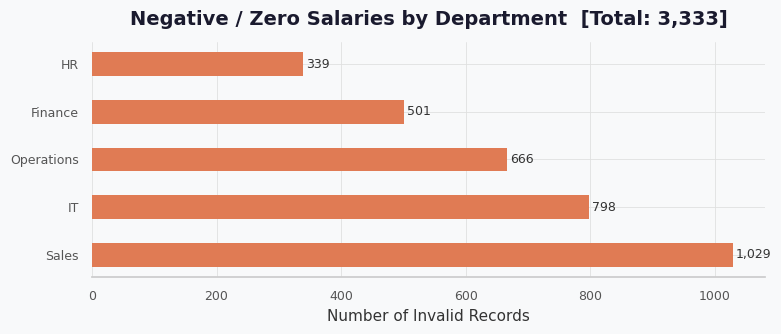

In [16]:
# ── 9.1 Negative Salaries ─────────────────────────────────────
neg_salary = df[df['Salary'] <= 0]
neg_by_dept = neg_salary.groupby('Department').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.5), facecolor=BG_COLOR)
bars = ax.barh(neg_by_dept.index, neg_by_dept.values,
               color='#E07B54', edgecolor='none', height=0.5)
for bar, val in zip(bars, neg_by_dept.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#333333')
ax.set_xlabel('Number of Invalid Records',  fontdict=FONT_LABEL)
ax.set_title(f'Negative / Zero Salaries by Department  [Total: {len(neg_salary):,}]',
              fontdict=FONT_TITLE, pad=12)
ax.tick_params(axis='both' , labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])
plt.tight_layout()
plt.show()

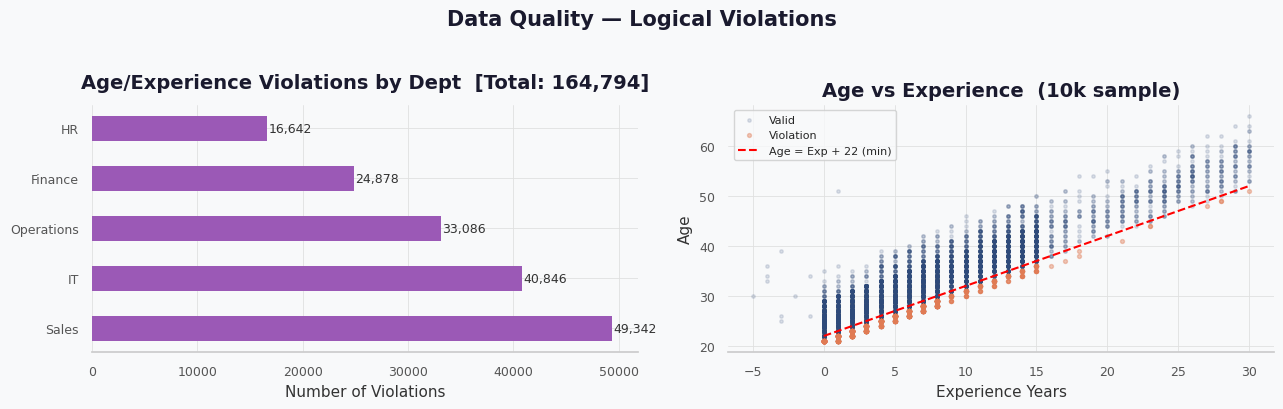

In [17]:
# ── 9.2 Age / Experience Violations ───────────────────────────
# Business rule: Age >= Experience_Years + 22
df['age_exp_violation'] = df['Age'] < (df['Experience_Years'] + 22)
violations = df[df['age_exp_violation']]
viol_by_dept = violations.groupby('Department').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

# Bar chart by dept
ax = axes[0]
ax.set_facecolor(BG_COLOR)
bars = ax.barh(viol_by_dept.index, viol_by_dept.values,
               color='#9B59B6', edgecolor='none', height=0.5)
for bar, val in zip(bars, viol_by_dept.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#333333')
ax.set_xlabel('Number of Violations',  fontdict=FONT_LABEL)
ax.set_title(f'Age/Experience Violations by Dept  [Total: {len(violations):,}]',
              fontdict=FONT_TITLE, pad=12)
ax.tick_params(axis='both' , labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

# Scatter: Age vs Experience, highlighting violations
ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)
sample = df.sample(10000, random_state=42)
valid_s = sample[~sample['age_exp_violation']]
viol_s  = sample[sample['age_exp_violation']]
ax2.scatter(valid_s['Experience_Years'], valid_s['Age'],
            alpha=0.15, s=6, color='#2E4A7A', label='Valid')
ax2.scatter(viol_s['Experience_Years'], viol_s['Age'],
            alpha=0.4, s=8, color='#E07B54', label='Violation')
# Reference line: Age = Exp + 22
x_ref = np.linspace(0, 30, 100)
ax2.plot(x_ref, x_ref + 22, color='red', lw=1.5,
         linestyle='--', label='Age = Exp + 22 (min)')
ax2.set_xlabel('Experience Years',  fontdict=FONT_LABEL)
ax2.set_ylabel('Age',  fontdict=FONT_LABEL)
ax2.set_title('Age vs Experience  (10k sample)',  fontdict=FONT_TITLE)
ax2.legend(fontsize=8)
ax2.tick_params(axis='both' , labelsize=FONT_TICK['fontsize'], labelcolor=FONT_TICK['color'])

plt.suptitle('Data Quality — Logical Violations', fontsize=15,
             fontweight='bold', color='#1A1A2E', y=1.02)
plt.tight_layout()
plt.show()

df.drop(columns=['age_exp_violation'], inplace=True)

> **Observations:**
> - **3,333 negative/zero salary records** — distributed relatively evenly across departments. Will be corrected using `PERCENTILE_CONT` median fallback by `(Department, Job_Level)` in SQL.
> - **164,794 Age/Experience violations** (~8.2% of records) — the scatter plot clearly shows the cluster of points below the business-rule boundary line. These will be corrected using domain-driven rules in the SQL cleaning phase.

---
## 13. Key Findings Summary

In [18]:
summary = {
    'Total Records'              : f"{len(df):,}",
    'Unique Employees'           : f"{df['Employee_ID'].nunique():,}",
    'Departments'                : df['Department'].nunique(),
    'Job Levels'                 : df['Job_Level'].nunique(),
    'Median Salary (valid)'      : f"${df[df['Salary']>0]['Salary'].median():,.0f}",
    '⚠ Negative Salaries'       : f"{(df['Salary']<=0).sum():,}  ({(df['Salary']<=0).mean()*100:.2f}%)",
    '⚠ Age/Exp Violations'      : f"{(df['Age']<df['Experience_Years']+22).sum():,}  ({(df['Age']<df['Experience_Years']+22).mean()*100:.1f}%)",
    '⚠ Missing Performance_Rating': f"{df['Performance_Rating'].isna().sum():,}  ({df['Performance_Rating'].isna().mean()*100:.3f}%)"
}

print('=' * 55)
print('           KEY FINDINGS SUMMARY')
print('=' * 55)
for k, v in summary.items():
    print(f'  {k:<35} {v}')
print('=' * 55)

           KEY FINDINGS SUMMARY
  Total Records                       2,000,000
  Unique Employees                    2,000,000
  Departments                         5
  Job Levels                          4
  Median Salary (valid)               $80,897
  ⚠ Negative Salaries                 3,333  (0.17%)
  ⚠ Age/Exp Violations                164,794  (8.2%)
  ⚠ Missing Performance_Rating        3,333  (0.167%)


---
## Next Steps

| Step | Action | File |
|------|--------|------|
| 1 | Load raw CSV into PostgreSQL | `etl/load_raw.py` |
| 2 | Fix negative salaries (median fallback) | `sql/02_cleaning.sql` |
| 3 | Correct Age/Experience violations | `sql/02_cleaning.sql` |
| 4 | Impute missing Performance_Rating | `sql/02_cleaning.sql` |
| 5 | Validate cleaned data | `sql/03_quality_checks.sql` |
| 6 | Build Kimball star schema (7 dims + fact) | `sql/04_star_schema.sql` |
| 7 | Validate mart schema (FK orphans, row counts) | `sql/05_mart_quality_checks.sql` |
| 8 | Build Power BI dashboard on `mart` schema | `powerbi/hr_analytics.pbix` |